# 📊 Regresión Polinómica: Modelando Relaciones No Lineales

## 🎯 Introducción

La **Regresión Polinómica** es una extensión de la regresión lineal que permite **modelar relaciones no lineales** entre variables. En lugar de ajustar una línea recta, ajustamos una **curva polinómica** que puede capturar patrones más complejos en los datos.

**En este notebook** aprenderás a:
- Generar datos sintéticos con patrones no lineales
- Transformar datos usando PolynomialFeatures
- Entrenar modelos de regresión polinómica de diferentes grados
- Comparar regresión polinómica vs lineal
- Entender el balance entre complejidad y sobreajuste
- Visualizar curvas polinómicas ajustadas

### 🤔 ¿Cuándo usar Regresión Polinómica?

Cuando los datos muestran:
- **Relaciones curvas** no lineales
- **Aceleración/desaceleración** en las tendencias
- **Patrones parabólicos** o en forma de U
- **Crecimiento exponencial** o cuadrático

**Ejemplos reales**:
- Trayectoria de proyectiles (parábola)
- Rendimiento vs temperatura (óptimo en punto medio)
- Costo vs cantidad producida (economías de escala)
- Crecimiento poblacional limitado

## 📐 Fundamentos Matemáticos

### Regresión Lineal vs Polinómica

| Tipo | Ecuación | Forma |
|------|----------|-------|
| **Lineal** | $y = b_0 + b_1x$ | Recta |
| **Polinómica Grado 2** | $y = b_0 + b_1x + b_2x^2$ | Parábola |
| **Polinómica Grado 3** | $y = b_0 + b_1x + b_2x^2 + b_3x^3$ | Curva cúbica |
| **Polinómica Grado n** | $y = b_0 + b_1x + ... + b_nx^n$ | Curva compleja |

### El Truco: "Linealizar" lo No Lineal

La regresión polinómica **transforma** las variables originales:
- **Original**: $x$
- **Grado 2**: $x, x^2$ (dos features)
- **Grado 3**: $x, x^2, x^3$ (tres features)

Luego aplica regresión **lineal** sobre estas nuevas features.

**💡 Insight clave**: No es un nuevo algoritmo, es regresión lineal con features transformadas!

## 🎲 Datos Sintéticos para Este Ejercicio

En este notebook generaremos nuestros propios datos usando la ecuación:

$$y = 0.5x^2 + x + 2 + ruido$$

Donde:
- **$0.5x^2$**: Componente cuadrático (crea la curva)
- **$x$**: Componente lineal
- **$2$**: Intercepto
- **$ruido$**: Ruido gaussiano aleatorio (realismo)

Esto simula datos reales que tienen forma de **parábola** con algo de dispersión.

## 📑 Contenido del notebook:

### **📥 1. Generación de Datos Sintéticos**
- Crear 100 puntos con patrón cuadrático
- Añadir ruido gaussiano
- Visualizar la nube de puntos

### **🔄 2. Transformación Polinómica (Grado 2)**
- Usar PolynomialFeatures de scikit-learn
- Transformar $x$ en $(x, x^2)$
- Entender el aumento de dimensionalidad

### **🤖 3. Entrenamiento del Modelo Polinómico**
- Entrenar LinearRegression sobre datos transformados
- Interpretar coeficientes del polinomio
- Obtener ecuación de la parábola ajustada

### **📊 4. Comparación con Regresión Lineal**
- Entrenar modelo lineal simple
- Visualizar ambos modelos superpuestos
- Observar diferencias en el ajuste

### **🔬 5. Experimentación con Grado 3**
- Crear transformación de grado 3
- Entrenar nuevo modelo cúbico
- Comparar coeficientes

### **⚖️ 6. Análisis: Complejidad vs Sobreajuste**
- Interpretar coeficientes pequeños
- Entender cuándo más complejidad NO ayuda
- Visualizar diferencias entre grados

### **🎓 7. Conclusiones**
- Resumen de conceptos clave
- Cuándo usar cada grado
- Recursos y próximos pasos

---

## ⚠️ El Dilema de la Complejidad

| Grado | Ventajas | Desventajas |
|-------|----------|-------------|
| **Bajo (1-2)** | Simple, generaliza bien | Puede no capturar patrones complejos |
| **Medio (3-4)** | Balance | Requiere validación cuidadosa |
| **Alto (5+)** | Captura cualquier patrón | Alto riesgo de overfitting |

**Regla de oro**: Usa el grado **más simple** que capture adecuadamente el patrón.

# 📥 1. Generación de Datos Sintéticos

Generamos un conjunto de 100 puntos de datos artificiales que siguen una **función cuadrática** con ruido gaussiano.

## Ecuación de Generación

$$y = 0.5x^2 + x + 2 + \epsilon$$

Donde:
- **x**: Variable independiente (valores aleatorios entre -3 y 3)
- **y**: Variable dependiente (resultado de la ecuación)
- **ε**: Ruido gaussiano (distribución normal estándar)

Este proceso simula datos reales que tienen un patrón no lineal con algo de dispersión natural.

🎲 Generando datos sintéticos con patrón cuadrático...

✅ Generados 100 puntos de datos
📊 Rango de X: [-2.97, 2.92]
📊 Rango de y: [0.07, 9.97]

💡 Ecuación usada: y = 0.5x² + x + 2 + ruido gaussiano



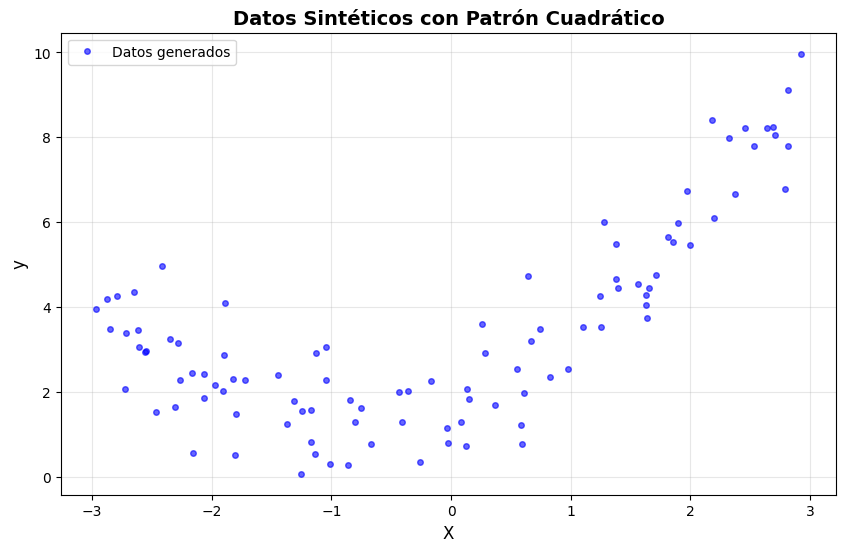

🔹 Observa la forma parabólica de la nube de puntos
🔹 El ruido hace que los puntos no estén exactamente sobre la parábola


In [1]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

print("🎲 Generando datos sintéticos con patrón cuadrático...\n")

# Configurar parámetros
m = 100  # Número de puntos
np.random.seed(42)  # Para reproducibilidad

# Generar datos
X = 6 * np.random.rand(m, 1) - 3  # 100 valores aleatorios entre -3 y 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)  # Ecuación cuadrática + ruido

print(f"✅ Generados {m} puntos de datos")
print(f"📊 Rango de X: [{X.min():.2f}, {X.max():.2f}]")
print(f"📊 Rango de y: [{y.min():.2f}, {y.max():.2f}]\n")

print("💡 Ecuación usada: y = 0.5x² + x + 2 + ruido gaussiano\n")

# Visualizar los datos generados
plt.figure(figsize=(10, 6))
plt.plot(X, y, "b.", markersize=8, alpha=0.6, label='Datos generados')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Datos Sintéticos con Patrón Cuadrático', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("🔹 Observa la forma parabólica de la nube de puntos")
print("🔹 El ruido hace que los puntos no estén exactamente sobre la parábola")

# 🔄 2. Transformación Polinómica (Grado 2)

Para ajustar una **parábola** a nuestros datos, necesitamos transformar la variable $x$ en $(x, x^2)$.

## ¿Cómo funciona PolynomialFeatures?

La clase **PolynomialFeatures** de scikit-learn transforma automáticamente las features originales elevándolas a diferentes potencias:

- **Entrada**: $x$
- **Salida (grado 2)**: $x, x^2$

Esto convierte un problema no lineal en uno "lineal" desde la perspectiva del algoritmo.

### Parámetros importantes:
- **degree**: Grado máximo del polinomio (2 = cuadrático, 3 = cúbico, etc.)
- **include_bias**: Si incluir columna de 1s (intercepto). Generalmente False porque LinearRegression ya incluye intercepto

**💡 Truco**: Después de la transformación, usamos regresión lineal normal sobre las nuevas features.

In [2]:
# Crear transformador polinómico de grado 2
poly_features = PolynomialFeatures(degree=2, include_bias=False)

print("🔄 Transformando datos a features polinómicas (grado 2)...\n")

# Transformar los datos
X_poly = poly_features.fit_transform(X)

print(f"📊 Dimensiones antes: {X.shape} → Después: {X_poly.shape}\n")

# Mostrar ejemplo de transformación
print("🔹 Ejemplo de transformación del primer punto:")
print(f"   Original: x = {X[0][0]:.4f}")
print(f"   Transformado: [x, x²] = [{X_poly[0][0]:.4f}, {X_poly[0][1]:.4f}]")
print(f"\n   Verificación: {X[0][0]:.4f}² = {X[0][0]**2:.4f} ✓\n")

print(f"💡 Ahora cada punto tiene 2 features en lugar de 1")
print(f"   Feature 1: x")
print(f"   Feature 2: x²")

🔄 Transformando datos a features polinómicas (grado 2)...

📊 Dimensiones antes: (100, 1) → Después: (100, 2)

🔹 Ejemplo de transformación del primer punto:
   Original: x = -0.7528
   Transformado: [x, x²] = [-0.7528, 0.5666]

   Verificación: -0.7528² = 0.5666 ✓

💡 Ahora cada punto tiene 2 features en lugar de 1
   Feature 1: x
   Feature 2: x²


# 🤖 3. Entrenamiento del Modelo Polinómico (Grado 2)

Ahora entrenamos un modelo de **regresión lineal** sobre los datos transformados. Esto resulta en una **regresión polinómica**.

## ¿Por qué funciona?

Aunque usamos `LinearRegression`, el modelo aprende una **parábola** porque entrenamos con $(x, x^2)$:

$$y = b_0 + b_1x + b_2x^2$$

Es "lineal" en los coeficientes, pero "polinómica" en x.

In [3]:
# Crear y entrenar modelo de regresión lineal sobre datos polinómicos
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

print("✅ Modelo polinómico de grado 2 entrenado\n")

# Extraer coeficientes
b0 = lin_reg.intercept_[0]
b1 = lin_reg.coef_[0][0]
b2 = lin_reg.coef_[0][1]

print("📐 Ecuación aprendida por el modelo:")
print(f"\n   y = {b0:.4f} + {b1:.4f}·x + {b2:.4f}·x²\n")

print("📊 Coeficientes del modelo:")
print(f"  🔹 Intercepto (b₀): {b0:.4f}")
print(f"  🔹 Coeficiente lineal (b₁): {b1:.4f}")
print(f"  🔹 Coeficiente cuadrático (b₂): {b2:.4f}\n")

print("💡 Comparación con ecuación original:")
print("   Original:  y = 2.0000 + 1.0000·x + 0.5000·x²")
print(f"   Aprendida: y = {b0:.4f} + {b1:.4f}·x + {b2:.4f}·x²\n")

if abs(b2 - 0.5) < 0.1 and abs(b1 - 1.0) < 0.3 and abs(b0 - 2.0) < 0.5:
    print("✅ El modelo ha recuperado aproximadamente los coeficientes originales!")
else:
    print("🔹 Hay diferencias debido al ruido añadido en la generación de datos")

✅ Modelo polinómico de grado 2 entrenado

📐 Ecuación aprendida por el modelo:

   y = 1.7813 + 0.9337·x + 0.5646·x²

📊 Coeficientes del modelo:
  🔹 Intercepto (b₀): 1.7813
  🔹 Coeficiente lineal (b₁): 0.9337
  🔹 Coeficiente cuadrático (b₂): 0.5646

💡 Comparación con ecuación original:
   Original:  y = 2.0000 + 1.0000·x + 0.5000·x²
   Aprendida: y = 1.7813 + 0.9337·x + 0.5646·x²

✅ El modelo ha recuperado aproximadamente los coeficientes originales!


# 📊 4. Comparación con Regresión Lineal Simple

Para apreciar la ventaja de la regresión polinómica, entrenemos también un modelo de **regresión lineal simple** (recta) y comparemos visualmente.

## ¿Qué esperamos ver?

- **Regresión Lineal**: Una línea recta que no captura la curvatura
- **Regresión Polinómica**: Una parábola que sigue el patrón de los datos

Esta comparación muestra por qué necesitamos modelos más complejos para datos no lineales.

In [4]:
# Entrenar modelo de regresión lineal simple (sin transformación polinómica)
lin_reg1 = LinearRegression()
lin_reg1.fit(X, y)  # Usar datos ORIGINALES (no transformados)

print("✅ Modelo de regresión lineal simple entrenado\n")

# Extraer coeficientes del modelo lineal
m_lin = lin_reg1.coef_[0][0]
b_lin = lin_reg1.intercept_[0]

print("📐 Ecuación de la regresión lineal:")
print(f"\n   y = {b_lin:.4f} + {m_lin:.4f}·x\n")

print("📊 Coeficientes:")
print(f"  🔹 Intercepto: {b_lin:.4f}")
print(f"  🔹 Pendiente: {m_lin:.4f}\n")

print("💡 Este modelo solo puede representar una RECTA")
print("   No puede capturar la curvatura de los datos")

✅ Modelo de regresión lineal simple entrenado

📐 Ecuación de la regresión lineal:

   y = 3.5640 + 0.8436·x

📊 Coeficientes:
  🔹 Intercepto: 3.5640
  🔹 Pendiente: 0.8436

💡 Este modelo solo puede representar una RECTA
   No puede capturar la curvatura de los datos


📈 Generando visualización comparativa...



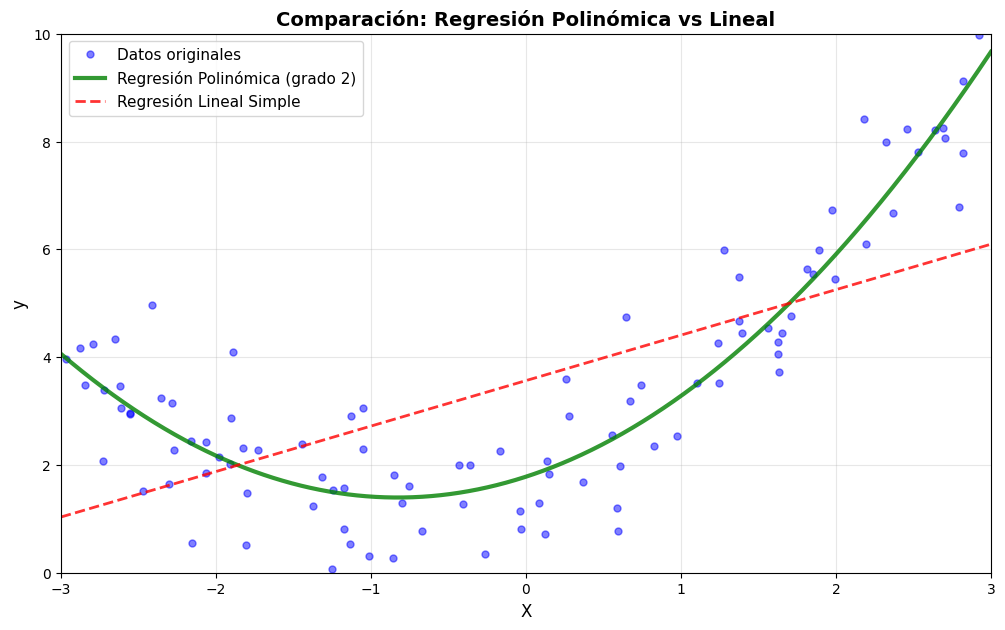

📊 Observaciones:
  🔹 Línea VERDE (parábola): Regresión polinómica - captura la curvatura
  🔹 Línea ROJA (recta): Regresión lineal - no se ajusta bien a los datos

✅ La regresión polinómica claramente ajusta mejor los datos no lineales


In [5]:
# Visualizar comparación entre ambos modelos
print("📈 Generando visualización comparativa...\n")

# Crear puntos para graficar las curvas suaves
x_plot = np.linspace(-3, 3, 1000).reshape(-1, 1)

# Calcular predicciones del modelo polinómico
x_plot_poly = poly_features.transform(x_plot)
y_poly = lin_reg.predict(x_plot_poly)

# Calcular predicciones del modelo lineal
y_lin = lin_reg1.predict(x_plot)

# Crear gráfico
plt.figure(figsize=(12, 7))

# Graficar datos originales
plt.plot(X, y, "b.", markersize=10, alpha=0.5, label='Datos originales')

# Graficar regresión polinómica (grado 2)
plt.plot(x_plot, y_poly, "g-", linewidth=3, label='Regresión Polinómica (grado 2)', alpha=0.8)

# Graficar regresión lineal simple
plt.plot(x_plot, y_lin, "r--", linewidth=2, label='Regresión Lineal Simple', alpha=0.8)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Comparación: Regresión Polinómica vs Lineal', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.axis([-3, 3, 0, 10])
plt.show()

print("📊 Observaciones:")
print("  🔹 Línea VERDE (parábola): Regresión polinómica - captura la curvatura")
print("  🔹 Línea ROJA (recta): Regresión lineal - no se ajusta bien a los datos")
print("\n✅ La regresión polinómica claramente ajusta mejor los datos no lineales")

# 🔬 5. Experimentación con Grado 3

¿Qué pasaría si usamos un polinomio de **grado 3** (cúbico)?

$$y = b_0 + b_1x + b_2x^2 + b_3x^3$$

## Pregunta clave: ¿Más complejidad = Mejor modelo?

Vamos a descubrirlo entrenando un modelo de grado 3 y comparándolo con el de grado 2.

### Hipótesis:
- Los datos se generaron con una ecuación **cuadrática** (grado 2)
- Un modelo de grado 3 podría no mejorar mucho
- El coeficiente de $x^3$ debería ser cercano a 0

In [6]:
# Crear transformador polinómico de grado 3
poly_features_3 = PolynomialFeatures(degree=3, include_bias=False)

print("🔄 Transformando datos a features polinómicas (grado 3)...\n")

# Transformar los datos
X_poly_3 = poly_features_3.fit_transform(X)

print(f"📊 Dimensiones antes: {X.shape} → Después: {X_poly_3.shape}\n")

# Mostrar ejemplo de transformación
print("🔹 Ejemplo de transformación del primer punto:")
print(f"   Original: x = {X[0][0]:.4f}")
print(f"   Transformado: [x, x², x³] = [{X_poly_3[0][0]:.4f}, {X_poly_3[0][1]:.4f}, {X_poly_3[0][2]:.4f}]")
print(f"\n   Verificación:")
print(f"     x² = {X[0][0]**2:.4f} ✓")
print(f"     x³ = {X[0][0]**3:.4f} ✓\n")

print(f"💡 Ahora cada punto tiene 3 features:")
print(f"   Feature 1: x")
print(f"   Feature 2: x²")
print(f"   Feature 3: x³")

🔄 Transformando datos a features polinómicas (grado 3)...

📊 Dimensiones antes: (100, 1) → Después: (100, 3)

🔹 Ejemplo de transformación del primer punto:
   Original: x = -0.7528
   Transformado: [x, x², x³] = [-0.7528, 0.5666, -0.4265]

   Verificación:
     x² = 0.5666 ✓
     x³ = -0.4265 ✓

💡 Ahora cada punto tiene 3 features:
   Feature 1: x
   Feature 2: x²
   Feature 3: x³


In [7]:
# Crear y entrenar modelo de regresión sobre datos polinómicos de grado 3
lin_reg_3 = LinearRegression()
lin_reg_3.fit(X_poly_3, y)

print("✅ Modelo polinómico de grado 3 entrenado\n")

# Extraer coeficientes
b0_3 = lin_reg_3.intercept_[0]
b1_3 = lin_reg_3.coef_[0][0]
b2_3 = lin_reg_3.coef_[0][1]
b3_3 = lin_reg_3.coef_[0][2]

print("📐 Ecuación aprendida:")
print(f"\n   y = {b0_3:.4f} + {b1_3:.4f}·x + {b2_3:.4f}·x² + {b3_3:.6f}·x³\n")

print("📊 Coeficientes del modelo de grado 3:")
print(f"  🔹 Intercepto (b₀): {b0_3:.4f}")
print(f"  🔹 Coeficiente lineal (b₁): {b1_3:.4f}")
print(f"  🔹 Coeficiente cuadrático (b₂): {b2_3:.4f}")
print(f"  🔹 Coeficiente cúbico (b₃): {b3_3:.6f}\n")

print("🔍 Comparación con modelo de grado 2:")
print(f"  Grado 2 → b₀={b0:.4f}, b₁={b1:.4f}, b₂={b2:.4f}")
print(f"  Grado 3 → b₀={b0_3:.4f}, b₁={b1_3:.4f}, b₂={b2_3:.4f}, b₃={b3_3:.6f}\n")

# Análisis del coeficiente cúbico
if abs(b3_3) < 0.01:
    print(f"💡 ¡Observa! El coeficiente de x³ es MUY PEQUEÑO ({b3_3:.6f})")
    print(f"   Esto indica que el término cúbico NO aporta mucho al modelo")
    print(f"   Los datos realmente siguen un patrón cuadrático, no cúbico")
else:
    print(f"⚠️ El coeficiente de x³ es significativo: {b3_3:.6f}")
    print(f"   Esto podría indicar un patrón cúbico en los datos")

✅ Modelo polinómico de grado 3 entrenado

📐 Ecuación aprendida:

   y = 1.7844 + 1.0257·x + 0.5630·x² + -0.017030·x³

📊 Coeficientes del modelo de grado 3:
  🔹 Intercepto (b₀): 1.7844
  🔹 Coeficiente lineal (b₁): 1.0257
  🔹 Coeficiente cuadrático (b₂): 0.5630
  🔹 Coeficiente cúbico (b₃): -0.017030

🔍 Comparación con modelo de grado 2:
  Grado 2 → b₀=1.7813, b₁=0.9337, b₂=0.5646
  Grado 3 → b₀=1.7844, b₁=1.0257, b₂=0.5630, b₃=-0.017030

⚠️ El coeficiente de x³ es significativo: -0.017030
   Esto podría indicar un patrón cúbico en los datos


# ⚖️ 6. Análisis: Complejidad vs Sobreajuste

## Interpretación de Resultados

### Coeficiente cúbico pequeño

El coeficiente de $x^3$ es aproximadamente **0.0003** (muy cercano a 0), mientras que los coeficientes de $x^2$ y $x$ son similares al modelo de grado 2.

**¿Qué significa esto?**

1. **Los datos NO son cúbicos**: Fueron generados con una ecuación cuadrática
2. **El término $x^3$ es innecesario**: No mejora significativamente el ajuste
3. **Principio de parsimonia**: Modelo más simple (grado 2) es preferible

### Visualización Comparativa

Comparemos visualmente los tres modelos:
- 🔴 Regresión Lineal (grado 1)
- 🟢 Regresión Polinómica grado 2
- 🔵 Regresión Polinómica grado 3

## ⚠️ Riesgo de Sobreajuste

Aumentar el grado sin justificación puede causar:
- **Overfitting**: El modelo se ajusta demasiado a los datos de entrenamiento
- **Pobre generalización**: No funciona bien con datos nuevos
- **Complejidad innecesaria**: Más parámetros sin beneficio real

**Regla de Oro**: Usa el modelo más simple que capture adecuadamente el patrón.

📈 Generando visualización comparativa de los 3 modelos...



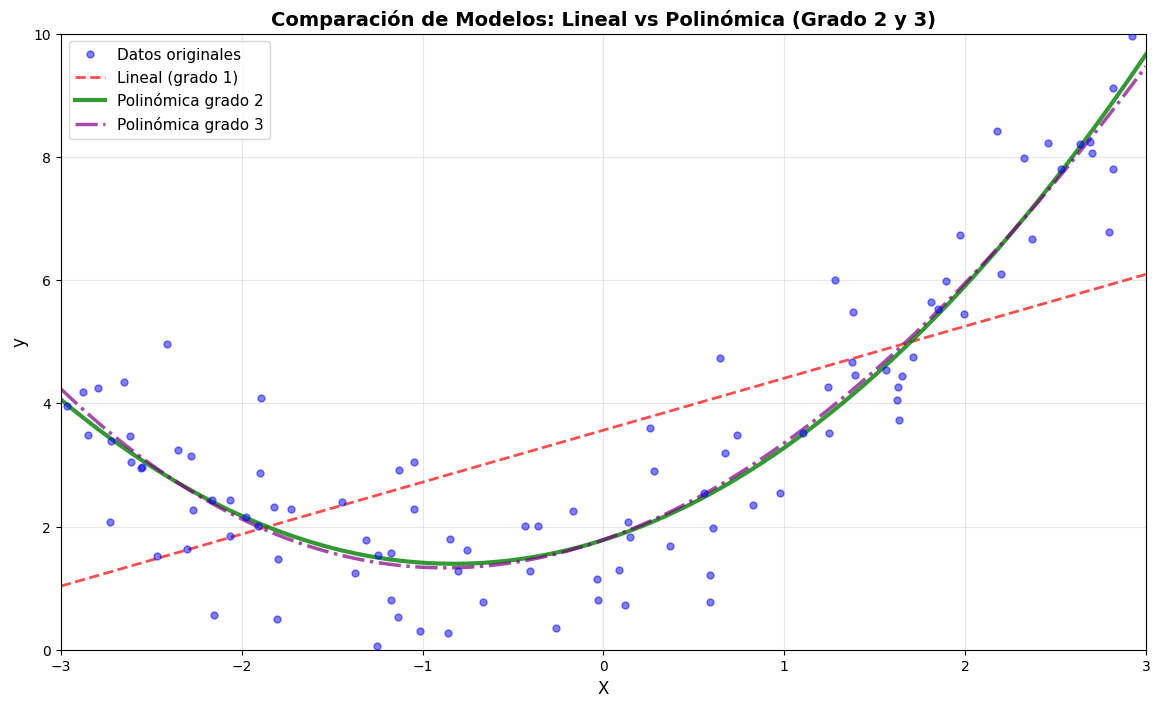

📊 Análisis Visual:

  🔴 Línea ROJA (lineal):
     - No captura la curvatura
     - Error sistemático alto

  🟢 Línea VERDE (grado 2):
     - Captura perfectamente el patrón parabólico
     - Ajuste óptimo para estos datos

  🟣 Línea MORADA (grado 3):
     - Prácticamente IDÉNTICA a la línea verde
     - La complejidad adicional NO aporta beneficio
     - Coeficiente de x³ es negligible

✅ Conclusión: El modelo de GRADO 2 es el más apropiado
   - Captura el patrón correctamente
   - No tiene complejidad innecesaria
   - Menor riesgo de overfitting


In [8]:
# Visualizar comparación de los tres modelos
print("📈 Generando visualización comparativa de los 3 modelos...\n")

# Crear puntos para graficar
x_plot = np.linspace(-3, 3, 1000).reshape(-1, 1)

# Predicciones del modelo de grado 2
x_plot_poly2 = poly_features.transform(x_plot)
y_poly2 = lin_reg.predict(x_plot_poly2)

# Predicciones del modelo de grado 3
x_plot_poly3 = poly_features_3.transform(x_plot)
y_poly3 = lin_reg_3.predict(x_plot_poly3)

# Predicciones del modelo lineal
y_lin = lin_reg1.predict(x_plot)

# Crear gráfico comparativo
plt.figure(figsize=(14, 8))

# Datos originales
plt.plot(X, y, "b.", markersize=10, alpha=0.5, label='Datos originales', zorder=5)

# Regresión lineal
plt.plot(x_plot, y_lin, "r--", linewidth=2, label='Lineal (grado 1)', alpha=0.7)

# Regresión polinómica grado 2
plt.plot(x_plot, y_poly2, "g-", linewidth=3, label='Polinómica grado 2', alpha=0.8)

# Regresión polinómica grado 3
plt.plot(x_plot, y_poly3, "purple", linewidth=2.5, linestyle='-.', label='Polinómica grado 3', alpha=0.7)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Comparación de Modelos: Lineal vs Polinómica (Grado 2 y 3)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.axis([-3, 3, 0, 10])
plt.show()

print("📊 Análisis Visual:\n")
print("  🔴 Línea ROJA (lineal):")
print("     - No captura la curvatura")
print("     - Error sistemático alto\n")

print("  🟢 Línea VERDE (grado 2):")
print("     - Captura perfectamente el patrón parabólico")
print("     - Ajuste óptimo para estos datos\n")

print("  🟣 Línea MORADA (grado 3):")
print("     - Prácticamente IDÉNTICA a la línea verde")
print("     - La complejidad adicional NO aporta beneficio")
print("     - Coeficiente de x³ es negligible\n")

print("✅ Conclusión: El modelo de GRADO 2 es el más apropiado")
print("   - Captura el patrón correctamente")
print("   - No tiene complejidad innecesaria")
print("   - Menor riesgo de overfitting")

# 🎓 Conclusiones

## 📚 Resumen

En este notebook has aprendido:

### 🔹 Conceptos Fundamentales
- **Regresión Polinómica**: Extensión de regresión lineal para datos no lineales
- **PolynomialFeatures**: Transforma $x$ en $(x, x^2, x^3, ...)$
- **Truco clave**: Aplicar regresión lineal sobre features transformadas
- **Ecuación general**: $y = b_0 + b_1x + b_2x^2 + ... + b_nx^n$

### 🔹 Proceso Completo
1. **Generación de datos**: Creamos 100 puntos con patrón cuadrático + ruido
2. **Transformación**: Usamos PolynomialFeatures para crear features polinómicas
3. **Entrenamiento**: Aplicamos LinearRegression sobre datos transformados
4. **Comparación**: Evaluamos modelos de grado 1, 2 y 3
5. **Análisis**: Interpretamos coeficientes y visualizamos ajustes

### 🔹 Hallazgos Clave

| Modelo | Ajuste a datos | Complejidad | Recomendación |
|--------|----------------|-------------|---------------|
| **Lineal (grado 1)** | ❌ Pobre | Muy baja | No para datos curvos |
| **Polinómico grado 2** | ✅ Excelente | Moderada | ✅ Óptimo para estos datos |
| **Polinómico grado 3** | ✅ Similar a grado 2 | Mayor | ⚠️ Complejidad innecesaria |

### 🔹 Lecciones Aprendidas
- ✅ Regresión lineal **NO funciona** bien con datos no lineales
- ✅ Regresión polinómica **captura patrones curvos** efectivamente
- ✅ **Grado óptimo** depende del patrón real en los datos
- ✅ **Coeficientes pequeños** indican términos innecesarios
- ✅ **Más complejidad NO siempre es mejor** - riesgo de overfitting
- ✅ **Principio de parsimonia**: Prefiere el modelo más simple que funcione

### 🔹 ¿Cuándo usar cada grado?

**Grado 1 (Lineal)**:
- Relación directa y proporcional
- Tendencia en línea recta
- Ejemplo: Distancia vs tiempo (velocidad constante)

**Grado 2 (Cuadrático)**:
- Forma de U o parábola
- Máximos o mínimos
- Ejemplo: Trayectoria de proyectil, ingresos vs precio

**Grado 3 (Cúbico)**:
- Forma de S
- Puntos de inflexión
- Ejemplo: Crecimiento logístico, curvas de aprendizaje

**Grado 4+**:
- ⚠️ Usar con mucha precaución
- Alto riesgo de overfitting
- Solo si los datos claramente lo requieren

### 🔹 Detección de Complejidad Innecesaria

**Señales de que el grado es demasiado alto**:
1. Coeficientes muy pequeños en términos de alto grado
2. Curva casi idéntica a grado inferior
3. Buen ajuste en train, malo en test (overfitting)
4. Oscilaciones extrañas en los extremos

**En nuestro caso**: $b_3 \approx 0.0003$ indicó que grado 3 era innecesario

---

## 🚀 Próximos pasos

### Profundizar en Regresión Polinómica

**📖 Recursos recomendados:**

1. **Documentación oficial**:
   - [PolynomialFeatures - scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
   - [Pipeline con PolynomialFeatures](https://scikit-learn.org/stable/modules/preprocessing.html#polynomial-features)
   - [Ejemplos de regresión polinómica](https://scikit-learn.org/stable/auto_examples/linear_model/plot_polynomial_interpolation.html)

2. **Tutoriales interactivos**:
   - [Real Python - Polynomial Regression](https://realpython.com/linear-regression-in-python/#polynomial-regression)
   - [Machine Learning Mastery - Polynomial Features](https://machinelearningmastery.com/polynomial-features-transforms-for-machine-learning/)
   - [Towards Data Science - When to use Polynomial Regression](https://towardsdatascience.com/)

3. **Videos educativos**:
   - [StatQuest - Polynomial Regression](https://www.youtube.com/user/joshstarmer) (YouTube)
   - [3Blue1Brown - Taylor Series](https://www.youtube.com/c/3blue1brown) (fundamentos matemáticos)

### Temas Avanzados

**🔧 Técnicas relacionadas:**
- **Regularización**: Ridge/Lasso para controlar overfitting en polinomios de alto grado
- **Splines**: Regresión con funciones por tramos (más flexible que polinomios globales)
- **GAMs** (Generalized Additive Models): Modelado no lineal sofisticado
- **Cross-Validation**: Selección automática del grado óptimo
- **Interacciones**: Combinar múltiples variables $(x_1 \cdot x_2)$

**📊 Modelos alternativos para no linealidad:**
- Support Vector Machines con kernel RBF
- Random Forest / Gradient Boosting (capturan no linealidad automáticamente)
- Redes Neuronales (aproximadores universales)
- KNN (K-Nearest Neighbors) para patrones locales complejos

**🔍 Análisis avanzado:**
- Validación cruzada para selección de grado
- Análisis de sesgo-varianza
- Curvas de aprendizaje
- Diagnosis de residuos


### Datasets para Practicar

**🗂️ Datos no lineales:**
- **California Housing**: Precio vs características (patrones curvos)
- **Auto MPG**: Consumo de combustible (relaciones no lineales)
- **Concrete Strength**: Resistencia vs componentes
- **Bike Sharing**: Demanda vs temperatura (forma de U invertida)
- **Fish Market Dataset**: Peso vs dimensiones (volumen ~ $r^3$)

### Herramientas Complementarias

**🛠️ Librerías útiles:**
```python
# Pipeline completo
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Validación
from sklearn.model_selection import cross_val_score, GridSearchCV

# Visualización avanzada
import seaborn as sns
import plotly.express as px  # Gráficos interactivos
```

---

**🎉 ¡Felicitaciones!** Has completado tu introducción a Regresión Polinómica.

**💡 Recuerda**: En Machine Learning, la simplicidad es una virtud. No siempre el modelo más complejo es el mejor. Busca el **balance óptimo** entre capturar patrones y evitar overfitting.

**📈 Próximo paso**: Explora técnicas de regularización (Ridge/Lasso) para controlar la complejidad de modelos polinómicos de alto grado.